In [22]:
from skimage import data
from skimage.transform import resize
import numpy as np

img = data.camera()
img = resize(img, (128,128), anti_aliasing=True)
img = img.astype(np.float32)
img = (img - img.min()) / (img.max() - img.min())

print(img.shape)

(128, 128)


In [23]:
def my_conv2d(img, kernel, stride=1, padding=0):

    H, W = img.shape
    K = kernel.shape[0]

    # padding
    padded = np.pad(img, ((padding,padding),(padding,padding)), mode='constant')

    H_out = (H + 2*padding - K)//stride + 1
    W_out = (W + 2*padding - K)//stride + 1

    assert H_out > 0 and W_out > 0

    out = np.zeros((H_out, W_out))

    for i in range(H_out):
        for j in range(W_out):
            region = padded[i*stride : i*stride+K, j*stride : j*stride+K]
            out[i,j] = np.sum(region * kernel)

    return out

sobel_x = np.array([
[-1,0,1],
[-2,0,2],
[-1,0,1]
])

sobel_y = np.array([
[-1,-2,-1],
[0,0,0],
[1,2,1]
])

edge_x = my_conv2d(img, sobel_x, stride=1, padding=1)
edge_y = my_conv2d(img, sobel_y, stride=1, padding=1)

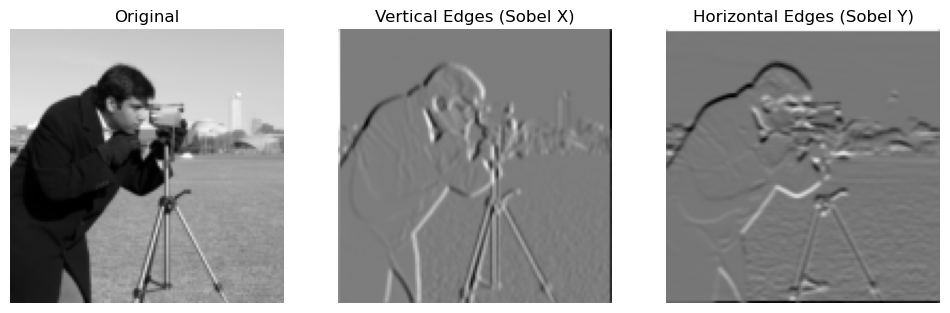

In [24]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Vertical Edges (Sobel X)")
plt.imshow(edge_x, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Horizontal Edges (Sobel Y)")
plt.imshow(edge_y, cmap='gray')
plt.axis('off')

os.makedirs(os.path.join("resources", "pics"), exist_ok=True)
plot_path = os.path.join("resources", "pics", "lab5(Sobel).png")
plt.savefig(plot_path, dpi=150)

plt.show()

In [25]:
def my_maxpool2d(img, kernel_size=2, stride=2):

    H, W = img.shape

    H_out = (H - kernel_size)//stride + 1
    W_out = (W - kernel_size)//stride + 1

    out = np.zeros((H_out, W_out))

    for i in range(H_out):
        for j in range(W_out):
            region = img[i*stride : i*stride+kernel_size, j*stride : j*stride+kernel_size]
            out[i,j] = np.max(region)

    return out

pooled = my_maxpool2d(img, kernel_size=2, stride=2)

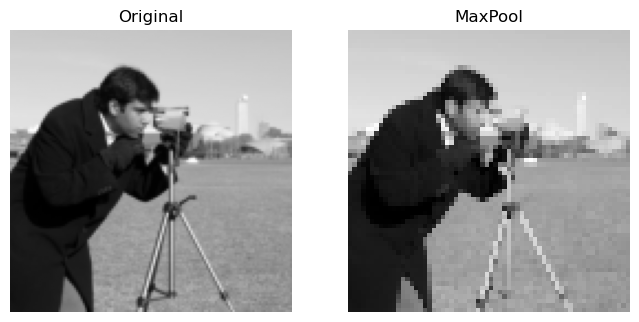

Original shape: (128, 128)
Pooled shape: (64, 64)


In [26]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("MaxPool")
plt.imshow(pooled, cmap='gray')
plt.axis('off')

os.makedirs(os.path.join("resources", "pics"), exist_ok=True)
plot_path = os.path.join("resources", "pics", "lab5(MaxPooling).png")
plt.savefig(plot_path, dpi=150)

plt.show()

print("Original shape:", img.shape)
print("Pooled shape:", pooled.shape)